# SC_scorecard.ipynb
**Author:** Emma McCallum  
**Purpose:** Synthesise findings from NB01 to NB05 into a five-axis reporting 
quality scorecard for five professional services firms  
**Input:** `data/processed/coverage_summary.csv`, `data/processed/transparency_scores.csv`, 
`data/processed/esrs_scores.csv`  
**Output:** `figures/scorecard_radar.png`

---

## What this scorecard measures

The scorecard does not rank firms by emissions size. It ranks them by reporting 
quality across five dimensions derived from the project analysis.

| Axis | Source | What it measures |
|------|--------|-----------------|
| Coverage breadth | NB02 | Percentage of 22 BEGES categories with a positive value |
| Methodology transparency | NB03 | Six-criterion transparency rubric scored 0 to 2, normalised to 100 |
| ESRS E1 readiness | NB04 | Eight-criterion readiness checklist scored 0 to 1, normalised to 100 |
| Inventory balance | NB02 and NB05 | Percentage of total emissions outside the top two categories, max-normalised |
| Transition plan disclosure | NB05 | Five-criterion rubric scored 0 to 1, normalised to 100 |

**Important caveat:** All scores are based on publicly available ADEME structured 
data and free-text fields. They measure what firms chose to disclose, not what 
they are actually doing. The transition plan axis in particular scores disclosure 
quality, not plan effectiveness.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import os

os.makedirs("../figures", exist_ok=True)

# ── Raw scores ────────────────────────────────────────────────────────────────

# Coverage breadth from NB02 (pct_reported, already 0-100)
coverage = {
    "Eco CO2":         63.6,
    "Antea France":    50.0,
    "Ecocert SA":      50.0,
    "Artelia":         45.5,
    "Bureau Veritas":  31.8,
}

# Methodology transparency from NB03 (total out of 12, normalise to 100)
transparency_raw = {
    "Artelia":         10,
    "Ecocert SA":       9,
    "Bureau Veritas":   8,
    "Antea France":     5,
    "Eco CO2":          6,
}
transparency = {k: round(v / 12 * 100, 1) for k, v in transparency_raw.items()}

# ESRS E1 readiness from NB04 (total out of 8, normalise to 100)
esrs_raw = {
    "Artelia":         6,
    "Eco CO2":         6,
    "Bureau Veritas":  4,
    "Ecocert SA":      4,
    "Antea France":    4,
}
esrs = {k: round(v / 8 * 100, 1) for k, v in esrs_raw.items()}

# Inventory balance (max-normalised rest percentage)
balance = {
    "Ecocert SA":      100.0,
    "Artelia":          86.0,
    "Antea France":     55.0,
    "Eco CO2":          14.0,
    "Bureau Veritas":   14.0,
}

# Transition plan disclosure quality (out of 5, normalise to 100)
transition_raw = {
    "Eco CO2":         5,
    "Artelia":         4,
    "Bureau Veritas":  3,
    "Ecocert SA":      2,
    "Antea France":    1,
}
transition = {k: round(v / 5 * 100, 1) for k, v in transition_raw.items()}

# ── Combine into dataframe ────────────────────────────────────────────────────
firms = ["Eco CO2", "Artelia", "Ecocert SA", "Bureau Veritas", "Antea France"]

scores = pd.DataFrame({
    "firm":              firms,
    "Coverage breadth":         [coverage[f] for f in firms],
    "Methodology transparency": [transparency[f] for f in firms],
    "ESRS E1 readiness":        [esrs[f] for f in firms],
    "Inventory balance":        [balance[f] for f in firms],
    "Transition plan disclosure": [transition[f] for f in firms],
}).set_index("firm")

print(scores)

                Coverage breadth  Methodology transparency  ESRS E1 readiness  \
firm                                                                            
Eco CO2                     63.6                      50.0               75.0   
Artelia                     45.5                      83.3               75.0   
Ecocert SA                  50.0                      75.0               50.0   
Bureau Veritas              31.8                      66.7               50.0   
Antea France                50.0                      41.7               50.0   

                Inventory balance  Transition plan disclosure  
firm                                                           
Eco CO2                      14.0                       100.0  
Artelia                      86.0                        80.0  
Ecocert SA                  100.0                        40.0  
Bureau Veritas               14.0                        60.0  
Antea France                 55.0               

In [2]:
import pandas as pd

t = pd.read_csv("../data/processed/transparency_scores.csv", index_col=0)
print(t)

                        Ecocert SA  Bureau Veritas  Antea France  Eco CO2  \
Criterion                                                                   
Boundary disclosed               1               1             1        1   
Consolidation stated             2               2             2        2   
Emission factors named           2               1             1        1   
Data sources described           2               1             1        1   
Uncertainty discussed            2               1             0        1   
Exclusions explained             0               2             0        0   
TOTAL                            9               8             5        6   

                        Artelia  
Criterion                        
Boundary disclosed            2  
Consolidation stated          2  
Emission factors named        1  
Data sources described        1  
Uncertainty discussed         2  
Exclusions explained          2  
TOTAL                        10  


## Scorecard analytical summary

The five axis scorecard reveals distinct reporting profiles across the five firms.
No firm scores consistently high across all dimensions, which is itself a finding.

**Artelia · Strongest overall profile**
Artelia leads on methodology transparency and also performs well on inventory
balance and transition plan disclosure. It is the only firm in this sample
with an SBTi commitment identified in the extracted fields. Its main weakness
is coverage breadth at 45.5 percent.

**Eco CO2 · Broadest coverage, weakest inventory balance**
Eco CO2 leads on coverage breadth and transition plan disclosure, and ties
with Artelia on ESRS E1 readiness. It has quantified targets and a structured
action plan. However, 91.6 percent of its emissions sit in the top two
categories and its methodology text is only moderate. Eco CO2 appears
strategically advanced but its inventory remains highly concentrated.

**Ecocert SA · Strongest methodology disclosure, weakest on targets**
Ecocert SA is strong on methodology transparency and inventory balance. It
provides the most detailed emission factor and uncertainty disclosure among
the five firms. Its main weakness is strategic target disclosure. No 2030
target or long term target appears in the extracted fields.

**Bureau Veritas · The diagnostic case**
Bureau Veritas has weak coverage breadth and weak inventory balance,
reflecting the concentration and gap issues identified in NB02 and NB05.
Its moderate scores elsewhere reflect a firm with strategic intent, but one
that has not yet connected its action plan to a reconciled inventory.

**Antea France · Weakest overall profile**
Antea France has moderate coverage breadth, but methodology transparency
and transition plan disclosure are both low. No targets are disclosed, and
the action plan was still in validation at the time of filing.

**Central finding**
The central finding of the project is that reporting breadth, methodology
transparency, inventory balance, ESRS E1 readiness, and strategic ambition
are related but not identical.

A firm can report many categories but still have a concentrated inventory.
A firm can disclose a serious methodology but lack strategic targets. A firm
can have an action plan but still lack a reconciled baseline.

No firm scores consistently high across all five dimensions. That is the
honest picture of where these five professional services firms stand on
climate reporting quality.

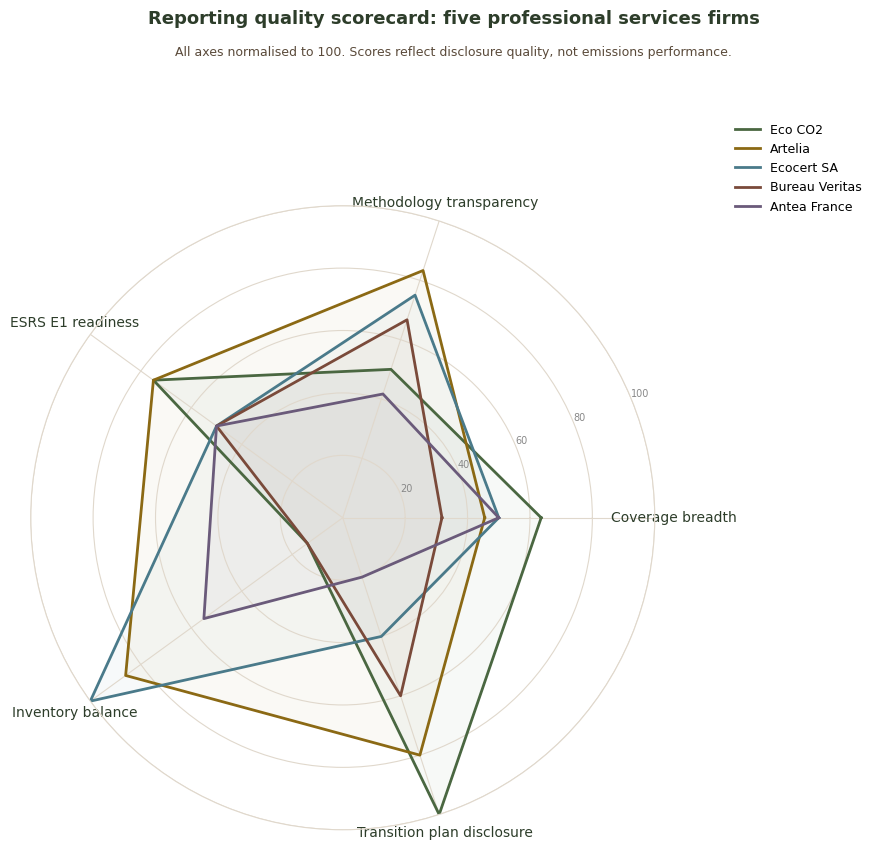

Saved.


In [3]:
axes = [
    "Coverage breadth",
    "Methodology transparency",
    "ESRS E1 readiness",
    "Inventory balance",
    "Transition plan disclosure",
]

n = len(axes)
angles = [i / n * 2 * np.pi for i in range(n)]
angles += angles[:1]

firm_colours = {
    "Eco CO2":         "#4a6741",   # deep forest green
    "Artelia":         "#8b6914",   # warm amber brown
    "Ecocert SA":      "#4a7a8a",   # slate teal
    "Bureau Veritas":  "#7a4a3a",   # terracotta
    "Antea France":    "#6a5a7a",   # muted purple
}
firm_edge_colours = {
      "Eco CO2":         "#4a6741",   # deep forest green
    "Artelia":         "#8b6914",   # warm amber brown
    "Ecocert SA":      "#4a7a8a",   # slate teal
    "Bureau Veritas":  "#7a4a3a",   # terracotta
    "Antea France":    "#6a5a7a",   # muted purple
}

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for firm in firms:
    values = [scores.loc[firm, a] for a in axes]
    values += values[:1]
    ax.plot(angles, values, linewidth=2,
            color=firm_edge_colours[firm], label=firm)
    ax.fill(angles, values, alpha=0.04,
            color=firm_colours[firm])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(axes, fontsize=10, color="#2d3d2a")
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(["20", "40", "60", "80", "100"],
                   fontsize=7, color="#888888")
ax.spines["polar"].set_color("#e0d8cc")
ax.grid(color="#e0d8cc", linewidth=0.8)

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.35, 1.15),
    fontsize=9,
    frameon=False,
)

fig.text(0.5, 0.97,
         "Reporting quality scorecard: five professional services firms",
         ha="center", va="top", fontsize=13,
         fontweight="bold", color="#2d3d2a")
fig.text(0.5, 0.93,
         "All axes normalised to 100. Scores reflect disclosure quality, not emissions performance.",
         ha="center", va="top", fontsize=9, color="#5a4a3a")

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.savefig("../figures/scorecard_radar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

## How to read this chart

The radar chart is a diagnostic profile rather than a definitive ranking. Each 
axis captures a different dimension of reporting quality. A strong profile is 
not only a large area on the chart, but a balanced shape across all five 
dimensions: coverage breadth, methodology transparency, ESRS E1 readiness, 
inventory balance, and transition plan disclosure.

A firm that scores high on one or two axes but collapses on others has an 
uneven reporting profile, which is itself an analytical finding. The chart is 
most useful for comparing shapes across firms, not absolute scores.

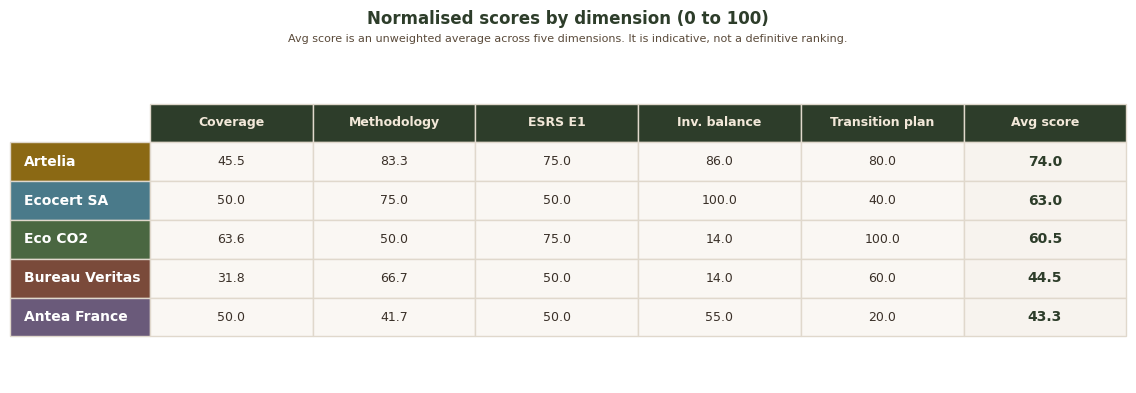

Saved.


In [4]:
# Summary score table
summary_table = scores.copy()
summary_table.columns = [
    "Coverage",
    "Methodology",
    "ESRS E1",
    "Inv. balance",
    "Transition plan",
]
summary_table["Avg score"] = summary_table.mean(axis=1).round(1)
summary_table = summary_table.sort_values("Avg score", ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")

col_labels = list(summary_table.columns)
row_labels = list(summary_table.index)
table_data = summary_table.values.round(1)

table = ax.table(
    cellText=table_data,
    rowLabels=row_labels,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.3, 2.2)

firm_row_colours = {
    "Artelia":         "#8b6914",
    "Eco CO2":         "#4a6741",
    "Ecocert SA":      "#4a7a8a",
    "Bureau Veritas":  "#7a4a3a",
    "Antea France":    "#6a5a7a",
}

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#e0d8cc")
    if row == 0:
        cell.set_facecolor("#2d3d2a")
        cell.set_text_props(fontweight="bold", color="#f2e8d9", fontsize=9)
    elif col == -1 and row > 0:
        firm = row_labels[row - 1]
        cell.set_facecolor(firm_row_colours.get(firm, "#f7f3ee"))
        cell.set_text_props(fontweight="bold", color="white", fontsize=10)
    elif col == len(col_labels) - 1:
        cell.set_facecolor("#f7f3ee")
        cell.set_text_props(fontweight="bold", color="#2d3d2a", fontsize=10)
    else:
        cell.set_facecolor("#faf7f3")
        cell.set_text_props(color="#3a3028", fontsize=9)

fig.text(0.5, 0.97,
         "Normalised scores by dimension (0 to 100)",
         ha="center", va="top", fontsize=12,
         fontweight="bold", color="#2d3d2a")
fig.text(0.5, 0.91,
         "Avg score is an unweighted average across five dimensions. It is indicative, not a definitive ranking.",
         ha="center", va="top", fontsize=8, color="#5a4a3a")

plt.tight_layout(rect=[0, 0, 1, 0.89])
plt.savefig("../figures/scorecard_table.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

## Final interpretation

The summary table confirms Artelia as the strongest overall profile in this
scorecard, with consistently high scores across methodology transparency,
ESRS E1 readiness, inventory balance, and transition plan disclosure.

Ecocert SA is second with 63.0, carried by methodology transparency and
inventory balance but pulled down by the absence of reduction targets. Eco CO2
follows at 60.5, strong on coverage and strategic disclosure but with a highly
concentrated inventory and only moderate methodology text. These two firms
illustrate that similar average scores can reflect fundamentally different
reporting strategies.

Bureau Veritas and Antea France score lower overall, though for different
reasons. Bureau Veritas is limited mainly by weak coverage breadth and
inventory balance, despite having a real action plan and a quantified 2030
target. Antea France is limited by weak methodology and transition plan
disclosure, with no targets disclosed at the time of filing.

The average score is useful as a synthesis indicator, but the individual
dimensions are more important than the ranking itself. The central finding
of this project is that reporting quality is multidimensional. Broad category
coverage, transparent methodology, strategic targets, balanced emissions
distribution, and transition plan disclosure do not necessarily move together.
A firm can lead on one dimension while being weak on another, and no single
metric is sufficient to assess the quality of a climate inventory.

In [5]:
import os

outputs = [
    "../figures/scorecard_radar.png",
    "../figures/scorecard_table.png",
]

for path in outputs:
    exists = os.path.exists(path)
    size = os.path.getsize(path) if exists else 0
    print(f"{'OK' if exists else 'MISSING'}  {path}  ({size:,} bytes)")

OK  ../figures/scorecard_radar.png  (257,814 bytes)
OK  ../figures/scorecard_table.png  (70,753 bytes)
